# Lotus Hotels Booking Analysis

## Project Objective
This project analyzes hotel booking behavior, customer cancellation patterns, pricing trends, and operational demand fluctuations for Lotus Hotels.

The objective is to identify:
- key operational inefficiencies
- revenue instability factors
- customer behavior patterns
- business opportunities for operational improvement

## Business Goals
- Understand cancellation behavior
- Identify high-risk customer segments
- Explore revenue volatility
- Analyze seasonal demand patterns
- Generate actionable business recommendations

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset Loading

The cleaned hotel booking dataset is loaded from the processed data layer.

In [ ]:
df = pd.read_csv("../data/processed/hotel_bookings_clean.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


# Initial Data Inspection

Initial exploratory analysis is performed to understand:
- dataset dimensions
- available business metrics
- customer-related fields
- operational data structure

In [10]:
df.shape

(87396, 32)

In [11]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [12]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            

# Initial Observations

## Observations
- Dataset contains hotel booking transaction records.
- Both operational and customer-related metrics are available.
- Booking cancellations, pricing, and stay duration metrics are included.
- Data includes both Resort Hotel and City Hotel operations.

## Potential Business Questions
- Which customers are most likely to cancel?
- Which hotel type experiences greater operational instability?
- How do pricing and booking timing affect cancellations?
- Are there seasonal demand fluctuations?

# Cancellation Analysis

This section investigates booking cancellation behavior to identify operational instability and high-risk customer segments.

In [6]:
cancellation_rate = df["is_canceled"].mean() * 100

print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Cancellation Rate: 27.49%


## Cancellation Rate Insight

The overall cancellation rate is approximately 27.5%, meaning more than 1 in 4 bookings are canceled.

### Business Implications
- Revenue forecasting may become unreliable.
- Staffing and room allocation planning may become inefficient.
- Operational instability may increase during peak periods.

In [ ]:
(
    df.groupby("customer_type")["is_canceled"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64

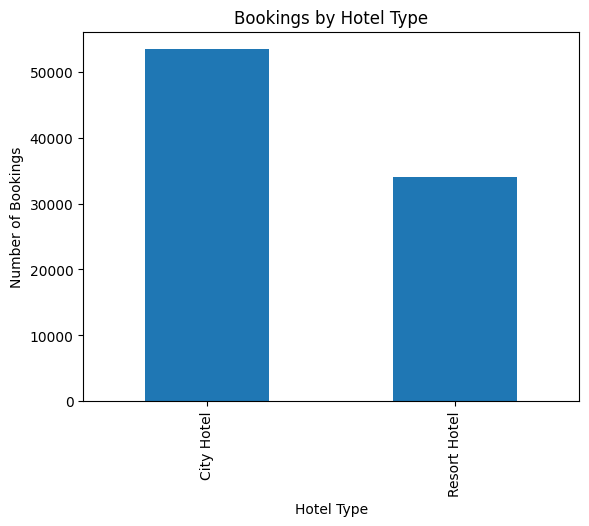

In [15]:
import matplotlib.pyplot as plt

df["hotel"].value_counts().plot(kind="bar")

plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

In [16]:
df["customer_type"].value_counts()

customer_type
Transient          71986
Transient-Party    11727
Contract            3139
Group                544
Name: count, dtype: int64

In [17]:
(
    df.groupby("customer_type")["is_canceled"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

customer_type
Transient          30.105854
Contract           16.310927
Transient-Party    15.238339
Group               9.926471
Name: is_canceled, dtype: float64

In [18]:
(
    df.groupby("hotel")["is_canceled"]
    .mean()
    * 100
)

hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64

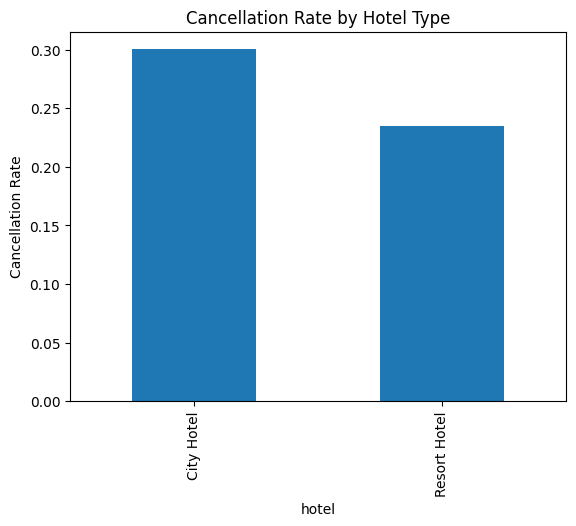

In [19]:
(
    df.groupby("hotel")["is_canceled"]
    .mean()
    .plot(kind="bar")
)

plt.title("Cancellation Rate by Hotel Type")
plt.ylabel("Cancellation Rate")

plt.show()

In [20]:
df["lead_time"].describe()

count    87396.000000
mean        79.891368
std         86.052325
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        737.000000
Name: lead_time, dtype: float64

In [21]:
df.groupby("is_canceled")["lead_time"].mean()

is_canceled
0     70.099588
1    105.719251
Name: lead_time, dtype: float64

# Key Findings

## Initial Observations
- Cancellation rate is significantly high at 27.49%.
- City Hotels generate the majority of bookings.
- Transient customers dominate booking activity.

## Business Concerns
- High cancellation rates may affect revenue forecasting.
- Operational planning may become inefficient due to booking instability.
- Transient customers may represent a higher-risk customer segment.

In [22]:
df["adr"].describe()

count    87396.000000
mean       106.337246
std         55.013953
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: adr, dtype: float64

In [23]:
df.groupby("is_canceled")["adr"].mean()

is_canceled
0    102.001961
1    117.772476
Name: adr, dtype: float64

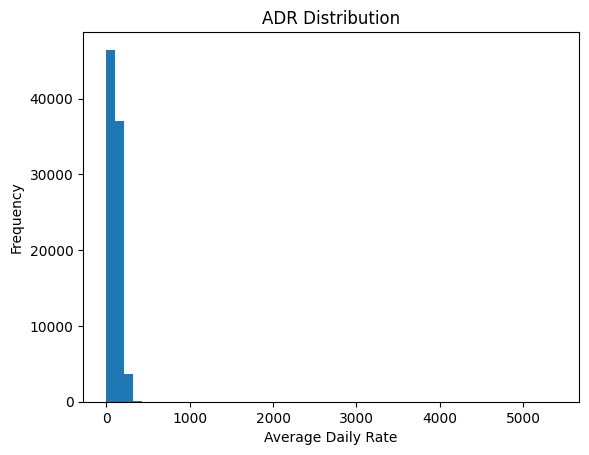

In [24]:
df["adr"].plot(kind="hist", bins=50)

plt.title("ADR Distribution")
plt.xlabel("Average Daily Rate")

plt.show()

In [25]:
df["adr"].sort_values(ascending=False).head(10)

38749    5400.00
80728     510.00
11661     508.00
74461     451.50
9984      450.00
10214     437.00
33093     426.25
33489     402.00
33056     397.38
10150     392.00
Name: adr, dtype: float64

In [26]:
df["arrival_date_month"].value_counts()

arrival_date_month
August       11257
July         10057
May           8355
April         7908
June          7765
March         7513
October       6934
September     6690
February      6098
December      5131
November      4995
January       4693
Name: count, dtype: int64

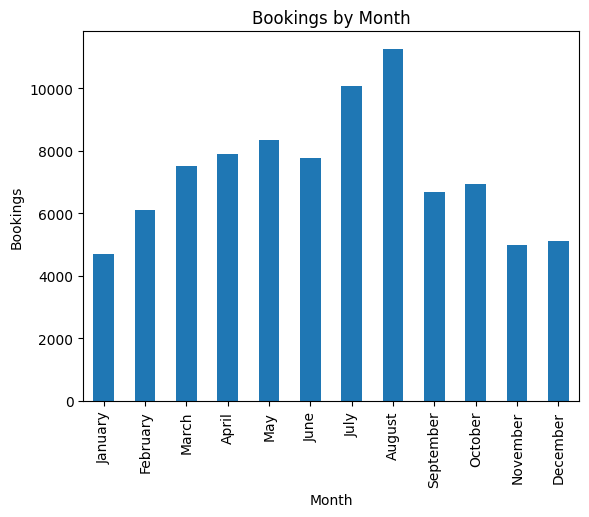

In [27]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_bookings = (
    df["arrival_date_month"]
    .value_counts()
    .reindex(month_order)
)

monthly_bookings.plot(kind="bar")

plt.title("Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Bookings")

plt.show()

## Cancellation Analysis
- Transient customers show the highest cancellation rate at approximately 30%.
- City Hotels experience higher cancellation rates compared to Resort Hotels.
- Long booking lead times may contribute to operational uncertainty.

## Operational Implications
- High-risk customer segments may require stricter booking policies.
- Revenue forecasting may be negatively impacted by cancellation volatility.
- Seasonal demand fluctuations may require dynamic staffing and pricing strategies.